In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos el dataset LIMPIO, no el original
df = pd.read_csv('../data/cafe_sales_clean.csv')

# Volvemos a convertir Transaction Date a datetime 
# (al guardar/cargar CSV, pandas pierde el tipo datetime y lo vuelve texto otra vez)
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Not Specified,Not Specified,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9942 entries, 0 to 9941
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9942 non-null   str           
 1   Item              9942 non-null   str           
 2   Quantity          9942 non-null   float64       
 3   Price Per Unit    9942 non-null   float64       
 4   Total Spent       9942 non-null   float64       
 5   Payment Method    9942 non-null   str           
 6   Location          9942 non-null   str           
 7   Transaction Date  9485 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 621.5 KB


In [3]:
ventas_por_item = df['Item'].value_counts()
ventas_por_item

Item
Juice            1167
Coffee           1158
Salad            1144
Cake             1134
Sandwich         1122
Smoothie         1089
Cookie           1084
Tea              1081
Not Specified     963
Name: count, dtype: int64

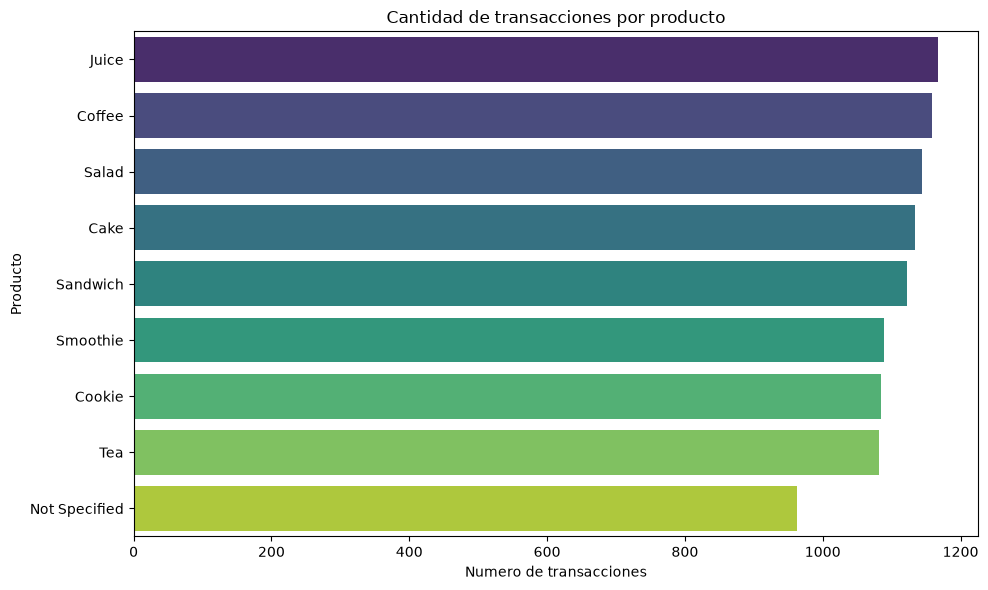

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_por_item.values, y=ventas_por_item.index, hue=ventas_por_item.index, palette='viridis', legend=False)
plt.title('Cantidad de transacciones por producto')
plt.xlabel('Numero de transacciones')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

## Hallazgo: Productos mas vendidos

Los 8 productos tienen un volumen de transacciones muy similar (entre ~950 y ~1,150), 
sin un producto dominante. Juice, Coffee y Salad lideran ligeramente. La categoria 
"Not Specified" (transacciones sin producto identificado) representa la menor 
proporcion, lo que sugiere que los valores faltantes en Item no estan sesgados 
hacia un producto en particular.

In [6]:
pago_counts = df['Payment Method'].value_counts()
pago_counts

Payment Method
Not Specified     3158
Digital Wallet    2280
Credit Card       2260
Cash              2244
Name: count, dtype: int64

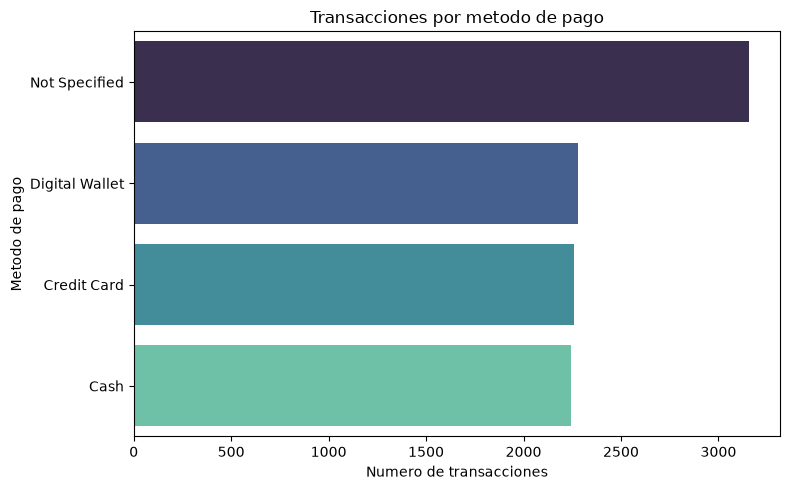

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x=pago_counts.values, y=pago_counts.index, hue=pago_counts.index, palette='mako', legend=False)
plt.title('Transacciones por metodo de pago')
plt.xlabel('Numero de transacciones')
plt.ylabel('Metodo de pago')
plt.tight_layout()
plt.show()

## Hallazgo: Metodo de pago

"Not Specified" es la categoria mas frecuente (~3,150 transacciones, ~32% del total), 
superando a los tres metodos de pago reales (Digital Wallet, Credit Card, Cash), que 
estan muy parejos entre si (~2,250 cada uno). Esto indica una tasa de dato faltante 
mucho mas alta en Payment Method que en Item, y podria señalar un problema sistematico 
en el registro de esta columna especifica.

In [8]:
location_counts = df['Location'].value_counts()
location_counts

Location
Not Specified    3940
Takeaway         3004
In-store         2998
Name: count, dtype: int64

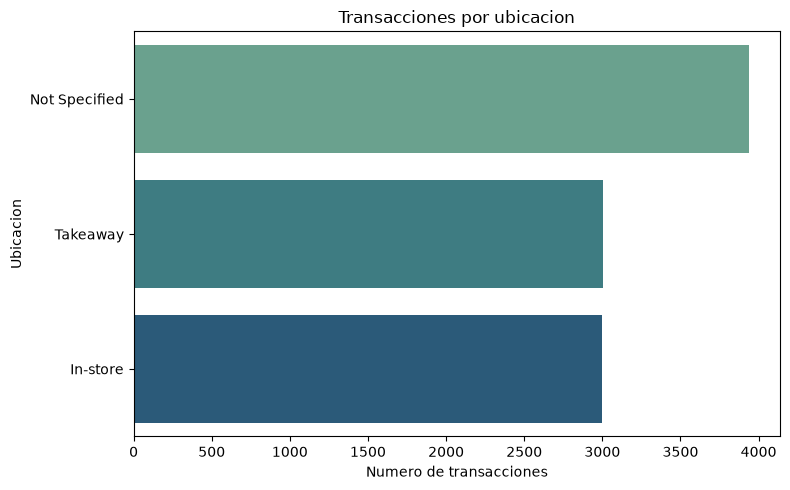

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=location_counts.values, y=location_counts.index, hue=location_counts.index, palette='crest', legend=False)
plt.title('Transacciones por ubicacion')
plt.xlabel('Numero de transacciones')
plt.ylabel('Ubicacion')
plt.tight_layout()
plt.show()

## Hallazgo: Ubicacion

"Not Specified" es la categoria mas grande (~3,950 transacciones, ~40% del total), 
superando a Takeaway e In-store, que estan practicamente empatados (~3,000 cada uno).

## Comparacion de calidad de dato entre columnas categoricas

| Columna | % Not Specified | Interpretacion |
|---|---|---|
| Item | ~10% | Baja tasa de dato faltante |
| Payment Method | ~32% | Tasa de dato faltante alta |
| Location | ~40% | La columna con peor calidad de dato del dataset |

Esto sugiere que el proceso de captura de Payment Method y Location tiene fallas 
mas frecuentes que el de Item, posiblemente por ser campos opcionales o de 
llenado manual en el sistema de origen.